In [1]:
import sionna.rt
import matplotlib.pyplot as plt
import numpy as np
import mitsuba as mi
import drjit as dr

from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, \
    PathSolver, RadioMapSolver, AntennaPattern, register_antenna_pattern

In [2]:
scene = load_scene(sionna.rt.scene.munich, merge_shapes=True) # Merge shapes to speed-up computations
scene.frequency = 3.5e9

In [3]:
# scene.preview();

In [4]:
if "tx" in scene.transmitters:
    scene.remove("tx")
if "rx" in scene.receivers:
    scene.remove("rx")

scene.tx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="cross")
tx = Transmitter(name="tx", position=[0,0,45], orientation=mi.Point3f(0,0,0), display_radius=10)
scene.add(tx)

scene.rx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="cross")
rx = Receiver(name="rx", position=[0,100,10], orientation=mi.Point3f(0,0,0), display_radius=10)
scene.add(rx)

# tx.look_at(rx) # Transmitter points towards receiver

In [5]:
p_solver  = PathSolver()
paths = p_solver(scene=scene,
                 max_depth=3,
                 los=True, specular_reflection=True, diffuse_reflection=False, refraction=True,
                 synthetic_array=False,
                 seed=41)

scene.preview(paths=paths)

In [40]:
# # Display all attributes and methods of paths object vertically
# attrs = dir(paths)
# print(f"Total attributes/methods: {len(attrs)}\n")
# for attr in attrs:
#     print(attr)

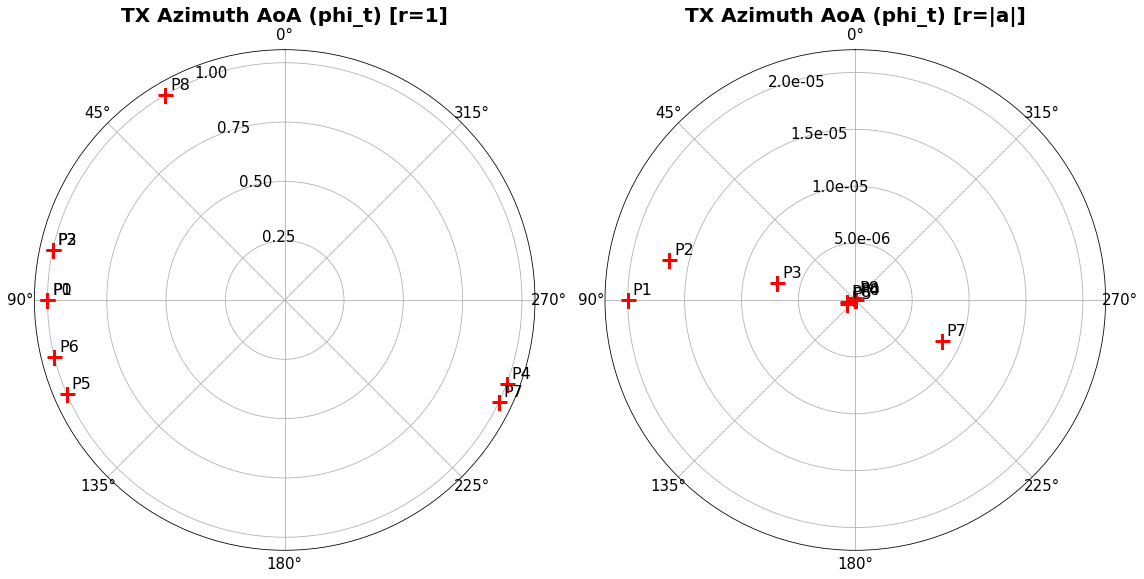

In [41]:
phi_t = paths.phi_t.numpy() if hasattr(paths.phi_t, 'numpy') else np.array(paths.phi_t)
phi_t_flat = phi_t[0, 0, 0, 0, :]  # 9 azimuth angles at TX

a, tau = paths.cir(normalize_delays=True, out_type="numpy")
a_abs = np.abs(a)[0, 0, 0, 0, :, 0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), subplot_kw=dict(projection='polar'))

theta_plot = phi_t_flat

r_plot_fixed = np.ones_like(theta_plot)
ax1.plot(theta_plot, r_plot_fixed, 'r+', markersize=15, markeredgewidth=3)

for i, (angle, r) in enumerate(zip(theta_plot, r_plot_fixed)):
    ax1.annotate(f'P{i}', xy=(angle, r), xytext=(5, 5), 
                textcoords='offset points', fontsize=16)

ax1.set_title('TX Azimuth AoA (phi_t) [r=1]', fontsize=20, fontweight='bold')
ax1.set_theta_zero_location('N')
ax1.set_theta_direction(1)
ax1.tick_params(axis='both', labelsize=15)
ax1.set_yticks([0.25, 0.5, 0.75, 1.0])
ax1.grid(True)

r_plot_amp = a_abs
ax2.plot(theta_plot, r_plot_amp, 'r+', markersize=15, markeredgewidth=3)

for i, (angle, r) in enumerate(zip(theta_plot, r_plot_amp)):
    ax2.annotate(f'P{i}', xy=(angle, r), xytext=(5, 5), 
                textcoords='offset points', fontsize=16)

ax2.set_title('TX Azimuth AoA (phi_t) [r=|a|]', fontsize=20, fontweight='bold')
ax2.set_theta_zero_location('N')
ax2.set_theta_direction(1)
ax2.tick_params(axis='both', labelsize=15)
# Set 4 evenly spaced circles
max_amp = np.max(a_abs)
ax2.set_ylim(0, max_amp * 1.1)  # Add 10% padding
ax2.set_yticks(np.linspace(0, max_amp, 5)[1:])  # 4 circles (exclude 0)
ax2.set_yticklabels([f'{val:.1e}' for val in np.linspace(0, max_amp, 5)[1:]])
ax2.grid(True)

plt.tight_layout()
plt.show()

In [44]:
phi_t_deg = np.rad2deg(phi_t_flat)
a, tau = paths.cir(normalize_delays=True, out_type="numpy")
tau_flat = tau[0, 0, 0, 0, :]

print("Path details (TX Azimuth vs Amplitude):")
print(f"{'Path':<5} {'phi_t (rad)':<15} {'phi_t (deg)':<15} {'tau (ns)':<15} {'|a| (x10^-6)':<15} {'|a| (dB)':<12}")
print("-" * 85)
for i, (angle_rad, angle_deg, delay, amp) in enumerate(zip(phi_t_flat, phi_t_deg, tau_flat, a_abs)):
    amp_db = 20 * np.log10(amp + 1e-10)  # Add small value to avoid log(0)
    print(f"{i:<5} {angle_rad:<15.5f} {angle_deg:<15.2f} {delay/1e-9:<15.5f} {amp*1e6:<15.6f} {amp_db:<12.2f}")

Path details (TX Azimuth vs Amplitude):
Path  phi_t (rad)     phi_t (deg)     tau (ns)        |a| (x10^-6)    |a| (dB)    
-------------------------------------------------------------------------------------
0     1.57080         90.00           0.00000         0.000002        -199.86     
1     1.57080         90.00           27.28228        20.028680       -93.97      
2     1.35958         77.90           286.12868       16.780396       -95.50      
3     1.35958         77.90           301.59958       7.034549        -103.06     
4     -1.93064        -110.62         650.10732       0.033034        -149.59     
5     1.97753         113.30          89.41953        0.792320        -122.02     
6     1.81294         103.87          368.12014       0.791689        -122.03     
7     -2.01671        -115.55         350.78841       8.428847        -101.48     
8     0.52773         30.24           578.74018       0.241285        -132.35     


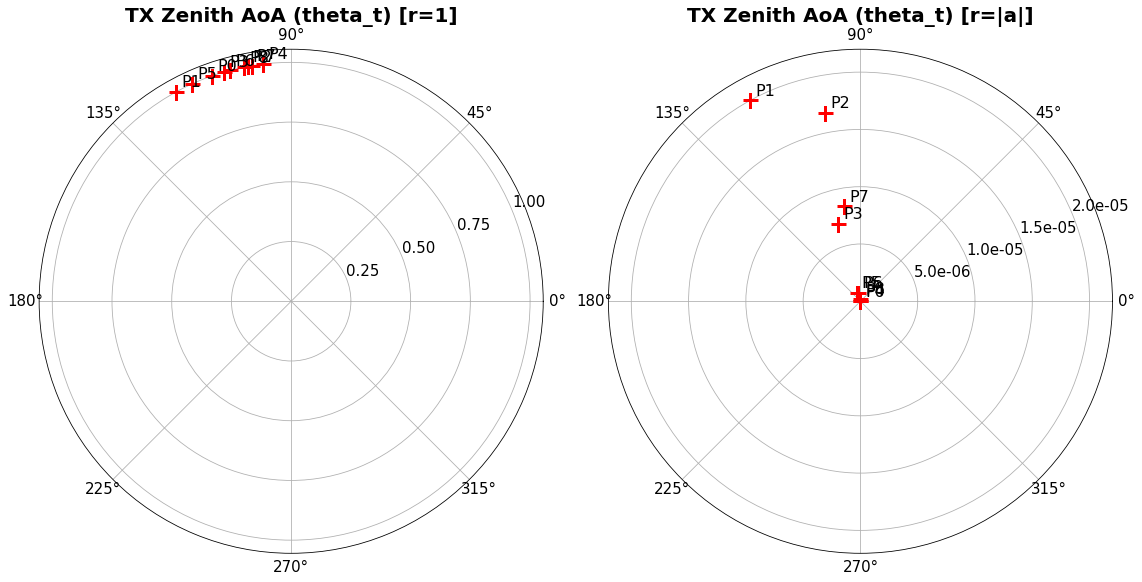

Path details (TX Zenith vs Amplitude):
Path  theta_t (rad)   theta_t (deg)   |a| (x10^-6)
-------------------------------------------------------
0     1.90747         109.29          0.000002    
1     2.07364         118.81          20.028680   
2     1.75438         100.52          16.780396   
3     1.85468         106.27          7.034549    
4     1.68740         96.68           0.033034    
5     1.99796         114.47          0.792320    
6     1.82788         104.73          0.791689    
7     1.73735         99.54           8.428847    
8     1.76890         101.35          0.241285    


In [36]:
theta_t = paths.theta_t.numpy() if hasattr(paths.theta_t, 'numpy') else np.array(paths.theta_t)
theta_t_flat = theta_t[0, 0, 0, 0, :]  # 9 Zenith angles at TX

a, tau = paths.cir(normalize_delays=True, out_type="numpy")
a_abs = np.abs(a)[0, 0, 0, 0, :, 0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), subplot_kw=dict(projection='polar'))

theta_plot = theta_t_flat

r_plot_fixed = np.ones_like(theta_plot)
ax1.plot(theta_plot, r_plot_fixed, 'r+', markersize=15, markeredgewidth=3)

for i, (angle, r) in enumerate(zip(theta_plot, r_plot_fixed)):
    ax1.annotate(f'P{i}', xy=(angle, r), xytext=(5, 5), 
                textcoords='offset points', fontsize=16)

ax1.set_title('TX Zenith AoA (theta_t) [r=1]', fontsize=20, fontweight='bold')
ax1.set_theta_zero_location('E')
ax1.set_theta_direction(1)
ax1.tick_params(axis='both', labelsize=15)
ax1.set_yticks([0.25, 0.5, 0.75, 1.0])
ax1.grid(True)

r_plot_amp = a_abs
ax2.plot(theta_plot, r_plot_amp, 'r+', markersize=15, markeredgewidth=3)

for i, (angle, r) in enumerate(zip(theta_plot, r_plot_amp)):
    ax2.annotate(f'P{i}', xy=(angle, r), xytext=(5, 5), 
                textcoords='offset points', fontsize=16)

ax2.set_title('TX Zenith AoA (theta_t) [r=|a|]', fontsize=20, fontweight='bold')
ax2.set_theta_zero_location('E')
ax2.set_theta_direction(1)
ax2.tick_params(axis='both', labelsize=15)
# Set 4 evenly spaced circles
max_amp = np.max(a_abs)
ax2.set_ylim(0, max_amp * 1.1)  # Add 10% padding
ax2.set_yticks(np.linspace(0, max_amp, 5)[1:])  # 4 circles (exclude 0)
ax2.set_yticklabels([f'{val:.1e}' for val in np.linspace(0, max_amp, 5)[1:]])
ax2.grid(True)

plt.tight_layout()
plt.show()

theta_t_deg = np.rad2deg(theta_t_flat)
print("Path details (TX Zenith vs Amplitude):")
print(f"{'Path':<5} {'theta_t (rad)':<15} {'theta_t (deg)':<15} {'|a| (x10^-6)':<12}")
print("-" * 55)
for i, (angle_rad, angle_deg, amp) in enumerate(zip(theta_t_flat, theta_t_deg, a_abs)):
    print(f"{i:<5} {angle_rad:<15.5f} {angle_deg:<15.2f} {amp*1e6:<12.6f}")

In [37]:
a, tau = paths.cir(normalize_delays=True, out_type="numpy")

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_steps]
print("Shape of a: ", a.shape)

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths]
print("Shape of tau: ", tau.shape)

Shape of a:  (1, 2, 1, 2, 9, 1)
Shape of tau:  (1, 2, 1, 2, 9)


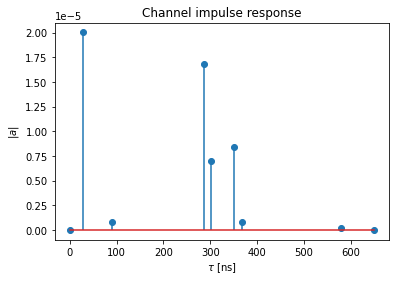

In [38]:
# CIR: channel impulse response

t = tau[0,0,0,0,:]/1e-9 # Scale to ns
a_abs = np.abs(a)[0,0,0,0,:,0]
a_max = np.max(a_abs)

plt.figure()
plt.title("Channel impulse response")
plt.stem(t, a_abs)
plt.xlabel(r"$\tau$ [ns]")
plt.ylabel(r"$|a|$");

## Approach 1: Post-Processing — Filter Paths by Departure Angles

Sionna uses **zenith** angle $\theta \in [0, \pi]$ (0° = up, 90° = horizon, 180° = down) and **azimuth** $\phi \in [-\pi, \pi]$.

To convert from the user-friendly **elevation** $\in [-90°, 90°]$: $\theta = 90° - \text{elevation}$

In [ ]:
def filter_paths_by_angle(paths, 
                          elevation_min=-90, elevation_max=90,
                          azimuth_min=-180, azimuth_max=180,
                          direction="departure"):
    """
    Filter CIR by departure or arrival angles.
    
    Parameters
    ----------
    paths : Paths object from PathSolver
    elevation_min, elevation_max : float
        Elevation limits in degrees [-90, 90]. 
        90° = zenith, 0° = horizon, -90° = nadir.
    azimuth_min, azimuth_max : float
        Azimuth limits in degrees [-180, 180].
    direction : str
        "departure" to filter by TX angles, "arrival" for RX angles.
    
    Returns
    -------
    a_filtered, tau : filtered CIR coefficients and delays (numpy)
    mask : boolean mask of kept paths
    """
    # Get angles (numpy)
    if direction == "departure":
        theta = paths.theta_t  # zenith angle [rad]
        phi = paths.phi_t      # azimuth angle [rad]
    else:
        theta = paths.theta_r
        phi = paths.phi_r
    
    # Convert to numpy if needed
    if hasattr(theta, 'numpy'):
        theta = theta.numpy()
        phi = phi.numpy()
    
    # Convert Sionna zenith (0=up, pi=down) to elevation (-90=down, 90=up)
    elevation = np.rad2deg(np.pi/2 - theta)
    azimuth = np.rad2deg(phi)
    
    # Build angular mask — shape: [num_rx, num_tx, num_paths]
    mask = ((elevation >= elevation_min) & (elevation <= elevation_max) &
            (azimuth >= azimuth_min) & (azimuth <= azimuth_max))
    
    # Get CIR
    a_cir, tau_cir = paths.cir(normalize_delays=True, out_type="numpy")
    # a shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_steps]
    # tau shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths]
    # mask shape: [num_rx, num_tx, num_paths] -> expand to match
    
    mask_a = mask[:, np.newaxis, :, np.newaxis, :, np.newaxis]   # for a
    mask_tau = mask[:, np.newaxis, :, np.newaxis, :]              # for tau
    
    # Zero out paths outside the angular window
    a_filtered = np.where(mask_a, a_cir, 0.0)
    
    return a_filtered, tau_cir, mask


# ---- Set your angular constraints here ----
ELEVATION_MIN = -10   # degrees
ELEVATION_MAX = 45    # degrees
AZIMUTH_MIN   = -60   # degrees
AZIMUTH_MAX   = 60    # degrees

a_filt, tau_filt, angle_mask = filter_paths_by_angle(
    paths,
    elevation_min=ELEVATION_MIN, elevation_max=ELEVATION_MAX,
    azimuth_min=AZIMUTH_MIN, azimuth_max=AZIMUTH_MAX,
    direction="departure"
)

total_paths = angle_mask.size
kept_paths = angle_mask.sum()
print(f"Angular window: elevation [{ELEVATION_MIN}°, {ELEVATION_MAX}°], azimuth [{AZIMUTH_MIN}°, {AZIMUTH_MAX}°]")
print(f"Paths kept: {kept_paths}/{total_paths} ({100*kept_paths/total_paths:.1f}%)")

In [ ]:
# Plot filtered vs unfiltered CIR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original CIR
t_orig = tau[0,0,0,0,:] / 1e-9
a_orig = np.abs(a)[0,0,0,0,:,0]
axes[0].stem(t_orig, a_orig)
axes[0].set_title("Original CIR (all paths)")
axes[0].set_xlabel(r"$\tau$ [ns]")
axes[0].set_ylabel(r"$|a|$")

# Filtered CIR
t_f = tau_filt[0,0,0,0,:] / 1e-9
a_f = np.abs(a_filt)[0,0,0,0,:,0]
axes[1].stem(t_f, a_f)
axes[1].set_title(f"Filtered CIR (el:[{ELEVATION_MIN}°,{ELEVATION_MAX}°], az:[{AZIMUTH_MIN}°,{AZIMUTH_MAX}°])")
axes[1].set_xlabel(r"$\tau$ [ns]")
axes[1].set_ylabel(r"$|a|$")

plt.tight_layout()
plt.show()

## Approach 2: Custom Antenna Pattern (Sector Pattern)

Register a custom antenna pattern that returns **zero gain** outside the desired angular window.
This affects the channel coefficients directly — paths outside the sector will have zero amplitude.
Rays are still traced in all directions, but only the sector contributes to the channel.

In [ ]:
from sionna.rt import PolarizedAntennaPattern, register_antenna_pattern

def make_sector_pattern(*, elevation_min=-90, elevation_max=90,
                         azimuth_min=-180, azimuth_max=180,
                         polarization, polarization_model="tr38901_2"):
    """
    Factory that creates a sector antenna pattern with angular constraints.
    
    Parameters
    ----------
    elevation_min, elevation_max : float
        Elevation limits in degrees [-90, 90].
    azimuth_min, azimuth_max : float
        Azimuth limits in degrees [-180, 180].
    polarization : str
        Antenna polarization ("V", "H", "cross", etc.)
    """
    # Convert user-friendly elevation to Sionna zenith convention
    # Sionna: theta=0 is up (zenith), theta=pi is down (nadir)
    # Elevation: +90 = up, 0 = horizon, -90 = down
    # So theta = pi/2 - elevation
    theta_min = np.deg2rad(90 - elevation_max)  # higher elevation → smaller zenith
    theta_max = np.deg2rad(90 - elevation_min)   # lower elevation → larger zenith
    phi_min = np.deg2rad(azimuth_min)
    phi_max = np.deg2rad(azimuth_max)
    
    def v_pattern(theta, phi):
        """Vertical component: 1 inside sector, 0 outside."""
        in_theta = (theta >= theta_min) & (theta <= theta_max)
        in_phi = (phi >= phi_min) & (phi <= phi_max)
        in_sector = in_theta & in_phi
        gain = dr.select(in_sector, mi.Float(1.0), mi.Float(0.0))
        return mi.Complex2f(gain, 0)
    
    def h_pattern(theta, phi):
        """Horizontal component: 1 inside sector, 0 outside."""
        in_theta = (theta >= theta_min) & (theta <= theta_max)
        in_phi = (phi >= phi_min) & (phi <= phi_max)
        in_sector = in_theta & in_phi
        gain = dr.select(in_sector, mi.Float(1.0), mi.Float(0.0))
        return mi.Complex2f(gain, 0)
    
    return PolarizedAntennaPattern(
        v_pattern=v_pattern,
        h_pattern=h_pattern,
        polarization=polarization,
        polarization_model=polarization_model
    )

# Register the pattern so it can be used by name
register_antenna_pattern("sector", make_sector_pattern)
print("Registered 'sector' antenna pattern.")

In [ ]:
# ---- Use the sector pattern on the transmitter ----
if "tx" in scene.transmitters:
    scene.remove("tx")
if "rx" in scene.receivers:
    scene.remove("rx")

# TX with sector-constrained antenna pattern
scene.tx_array = PlanarArray(
    num_rows=1, num_cols=1,
    pattern="sector",
    elevation_min=-10,    # <-- set your elevation limits (degrees)
    elevation_max=45,
    azimuth_min=-60,      # <-- set your azimuth limits (degrees)
    azimuth_max=60,
    polarization="cross"
)
tx = Transmitter(name="tx", position=[15, 25, 30], display_radius=10)
scene.add(tx)

# RX with standard isotropic pattern
scene.rx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="cross")
rx = Receiver(name="rx", position=[45, 90, 10], display_radius=10)
scene.add(rx)
tx.look_at(rx)

# Solve paths
p_solver2 = PathSolver()
paths2 = p_solver2(scene=scene, max_depth=3,
                   los=True, specular_reflection=True, 
                   diffuse_reflection=False, refraction=True,
                   synthetic_array=False, seed=41)

# Plot CIR
a2, tau2 = paths2.cir(normalize_delays=True, out_type="numpy")

t2 = tau2[0,0,0,0,:] / 1e-9
a2_abs = np.abs(a2)[0,0,0,0,:,0]

plt.figure()
plt.title("CIR with sector-constrained TX antenna")
plt.stem(t2, a2_abs)
plt.xlabel(r"$\tau$ [ns]")
plt.ylabel(r"$|a|$")
plt.show()

print(f"Number of non-zero paths: {np.count_nonzero(a2_abs)}")